In [1]:
#import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from tarnet import Tarnet
import sys
from pathlib import Path
project_root = Path("/home/ducvu0904/Documents/Lab/RERUM")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
from utils import seed_everything
from metrics import auuc, auqc, lift, krcc

In [2]:
%time train_df = pd.read_csv(r"../dataset/Hillstrom/Men/train_men.csv")
%time test_df =  pd.read_csv(r"../dataset/Hillstrom/Men/test_men.csv")
%time val_df = pd.read_csv(r"../dataset/Hillstrom/Men/val_men.csv")

CPU times: user 10.1 ms, sys: 4.99 ms, total: 15 ms
Wall time: 14.5 ms
CPU times: user 4.77 ms, sys: 1.97 ms, total: 6.74 ms
Wall time: 6.73 ms
CPU times: user 3.06 ms, sys: 9 μs, total: 3.07 ms
Wall time: 3.07 ms


In [3]:
in_features = ['recency', 'history_segment', 'history', 'mens', 'womens',
       'zip_code', 'newbie', 'channel_Multichannel', 'channel_Phone', 'channel_Web']
label_feature = ['spend']
treatment_feature = ['treatment']

In [4]:
# 1. Định nghĩa danh sách các cột (Bạn hãy điều chỉnh tên cột đúng với dữ liệu của mình)
cat_features = ['zip_code', 'channel', 'history_segment'] # Các biến phân loại (đã LabelEncode)
num_features = ['recency', 'history', 'mens', 'womens']     # Các biến số thực (đã Scale)

def prepare_tensors(df):
    """Hàm hỗ trợ chuyển đổi DataFrame thành các Tensor riêng biệt"""
    # Tách dữ liệu
    X_cat = torch.LongTensor(df[cat_features].values)    # Kiểu Long cho Embedding 
    X_num = torch.FloatTensor(df[num_features].values)  # Kiểu Float cho Projection 
    
    # Biến mục tiêu
    t = torch.FloatTensor(df['treatment'].values).unsqueeze(1)
    y = torch.FloatTensor(df['spend'].values).unsqueeze(1) # Lưu ý: Nên là log(1+y) [cite: 191]
    
    return X_cat, X_num, t, y

# 2. Chuyển đổi cho cả 3 tập dữ liệu [cite: 390]
train_cat, train_num, t_train, y_train = prepare_tensors(train_df)
val_cat, val_num, t_val, y_val = prepare_tensors(val_df)
test_cat, test_num, t_test, y_test = prepare_tensors(test_df)

# 3. Khởi tạo TensorDataset với cấu trúc 4 tham số
train_dataset = TensorDataset(train_cat, train_num, t_train, y_train)
val_dataset = TensorDataset(val_cat, val_num, t_val, y_val)
test_dataset = TensorDataset(test_cat, test_num, t_test, y_test)

# 4. Khởi tạo DataLoader [cite: 398, 419]
# Với 5060Ti, batch_size=1024 hoặc 2048 là tối ưu để gradient không quá phẳng
batch_size = 1024 

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 5. Thông tin để khởi tạo Model
cat_dims = [train_df[col].nunique() for col in cat_features]
num_count = len(num_features)

print(f"Mô hình sẽ có {len(cat_dims)} lớp Embedding và {num_count} lớp Projection.")

Mô hình sẽ có 3 lớp Embedding và 4 lớp Projection.


/tmp/ipykernel_1369710/1902134193.py:12: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  t = torch.FloatTensor(df['treatment'].values).unsqueeze(1)


In [5]:
epochs = 150
early_stop_metric = "ema_qini"
ema = True
ema_alpha = 0.25
patience = 20
early_stop_start = 30
print (f" epochs = {epochs}")
print (f" early stop = {early_stop_metric}")
print (f" use ema = {ema}")
print (f" ema alpha = {ema_alpha}")
print (f" patience = {patience}")
print (f" early stop start = {early_stop_start}")

 epochs = 150
 early stop = ema_qini
 use ema = True
 ema alpha = 0.25
 patience = 20
 early stop start = 30


In [6]:
import io
import optuna
from contextlib import redirect_stdout, redirect_stderr

# Minimize Optuna console noise
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 1. Optuna search config (validation only)
seeds = [412312, 42, 1874, 902745, 1]
n_trials = 100
tpe_sampler_seed = 412312
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def objective(trial):
    grid_lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    grid_wd = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    grid_outcome_dropout = trial.suggest_float("outcome_dropout", 0.0, 0.7)
    grid_shared_dropout = trial.suggest_float("shared_dropout", 0.0, 0.7)
    grid_shared_hidden = trial.suggest_int("shared_hidden", 32, 1000)
    grid_outcome_hidden = trial.suggest_int("outcome_hidden", 32, 1000)
    grid_ziln_lambda = trial.suggest_float("ziln_lambda", 1e-4, 0.1, log=True)
    grid_pos_weight = trial.suggest_float("pos_weight", 1.0, 99.0, log=True)
    grid_ema_alpha = trial.suggest_float("ema_alpha", 0.1, 0.4)
    

    val_auqc_list = []
    val_ate_err_list = []
    for SEED in seeds:
        seed_everything(SEED)

        tarnet = Tarnet(
            cate_dims=cat_dims,
            num_count=num_count,
            epochs=epochs,
            learning_rate=grid_lr,
            weight_decay=grid_wd,
            use_ema=ema,
            ema_alpha=grid_ema_alpha,
            patience=patience,
            shared_hidden=grid_shared_hidden,
            outcome_hidden=grid_outcome_hidden,
            outcome_dropout=grid_outcome_dropout,
            shared_dropout=grid_shared_dropout,
            early_stop_metric=early_stop_metric,
            early_stop_start_epoch=early_stop_start,
            ziln_lambda=grid_ziln_lambda,
            pos_weight=grid_pos_weight
        )

        with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
            tarnet.fit(train_loader, val_loader)

        val_cat_device = val_cat.to(device)
        val_num_device = val_num.to(device)

        y0_pred, y1_pred = tarnet.predict(val_cat_device, val_num_device)

        uplift_pred = (y1_pred - y0_pred).detach().cpu().numpy().flatten()
        y_true = y_val.detach().cpu().numpy().flatten()
        t_true = t_val.detach().cpu().numpy().flatten()

        current_val_auqc = auqc(y_true, t_true, uplift_pred, bins=100, plot=False)
        ate_pred = uplift_pred.mean()
        ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()
        current_val_ate_err = abs(ate_pred - ate_true)

        val_auqc_list.append(current_val_auqc)
        val_ate_err_list.append(current_val_ate_err)

    # Calculate aggregated metrics across the 5 validation seeds
    mean_auqc = float(np.mean(val_auqc_list))
    std_auqc = float(np.std(val_auqc_list))
    mean_ate_err = float(np.mean(val_ate_err_list))

    # Apply penalty for instability and miscalibration
    penalty_std = std_auqc
    final_score = mean_auqc - penalty_std 

    trial.set_user_attr("mean_val_auqc", mean_auqc)
    trial.set_user_attr("std_Val_auqc", std_auqc)
    trial.set_user_attr("mean_val_ate_err", mean_ate_err)
    trial.set_user_attr("final_score", final_score)
    return final_score

def print_trial_callback(study, trial):
    value = float(trial.value) if trial.value is not None else float("nan")
    completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]

    if not completed_trials:
        print(
            f"Finished trial {trial.number}: val score: {value:.4f} - "
            f"with hyperparameters: {trial.params} | "
            "best trial: N/A (no completed trials yet)",
            flush=True,
        )
        return

    best_trial = study.best_trial
    best_value = float(best_trial.value) if best_trial.value is not None else float("nan")
    print(
        f"Finished trial {trial.number}: val score: {value:.4f} - "
        f"with hyperparameters: {trial.params} | "
        f"best trial: {best_trial.number} score: {best_value:.4f}",
        flush=True,
    )

sampler = optuna.samplers.TPESampler(seed=tpe_sampler_seed)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=n_trials, show_progress_bar=True, callbacks=[print_trial_callback])

trial_rows = []
for t in study.trials:
    if t.value is None:
        continue
    trial_rows.append({
        "trial": t.number,
        "lr": round(float(t.params["lr"]), 4),
        "weight_decay": round(float(t.params["weight_decay"]), 4),
        "shared_hidden": int(t.params["shared_hidden"]),
        "outcome_hidden": int(t.params["outcome_hidden"]),
        "shared_dropout": round(float(t.params["shared_dropout"]), 3),
        "outcome_dropout": round(float(t.params["outcome_dropout"]), 3),
        "ziln_lambda": round(float(t.params["ziln_lambda"]), 3),
        "pos_weight": round(float(t.params["pos_weight"]), 3),
        "ema_alpha": round(float(t.params["ema_alpha"]), 3),
        "mean_val_auqc": float(t.value),
        "std_Val_auqc": float(t.user_attrs.get("std_Val_auqc", np.nan))
    })

df_grid = pd.DataFrame(trial_rows).sort_values("mean_val_auqc", ascending=True).reset_index(drop=True)
best_params = study.best_params
best_cfg = pd.Series({
    "lr": float(best_params["lr"]),
    "weight_decay": float(best_params["weight_decay"]),
    "shared_hidden": int(best_params["shared_hidden"]),
    "outcome_hidden": int(best_params["outcome_hidden"]),
    "shared_dropout": float(best_params["shared_dropout"]),
    "outcome_dropout": float(best_params["outcome_dropout"]),
    "ziln_lambda": float(best_params["ziln_lambda"]),
    "pos_weight": float(best_params["pos_weight"]),
    "ema_alpha": float(best_params["ema_alpha"]),
    "mean_Val_auqc": float(study.best_value),
    "std_Val_auqc": float(study.best_trial.user_attrs.get("std_Val_auqc", np.nan))
})

/home/ducvu0904/miniconda3/envs/ai/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  0%|          | 0/100 [00:00<?, ?it/s]

Finished trial 0: val score: 0.7975 - with hyperparameters: {'lr': 9.008296332262975e-05, 'weight_decay': 3.2543813547868006e-05, 'outcome_dropout': 0.285791981486852, 'shared_dropout': 0.3103695462655224, 'shared_hidden': 615, 'outcome_hidden': 826, 'ziln_lambda': 0.06371867322051755, 'pos_weight': 89.84623696409173, 'ema_alpha': 0.27706978682774963} | best trial: 0 score: 0.7975


Best trial: 0. Best value: 0.797466:   1%|          | 1/100 [01:38<2:42:18, 98.37s/it]

Finished trial 1: val score: 0.8920 - with hyperparameters: {'lr': 0.00030036518432024714, 'weight_decay': 0.0018865375430062972, 'outcome_dropout': 0.21781161962472378, 'shared_dropout': 0.2919863338576562, 'shared_hidden': 198, 'outcome_hidden': 241, 'ziln_lambda': 0.010085829414078899, 'pos_weight': 34.00544279483954, 'ema_alpha': 0.2821789066860085} | best trial: 1 score: 0.8920


Best trial: 1. Best value: 0.891989:   2%|▏         | 2/100 [03:08<2:32:30, 93.37s/it]

...

Best trial: 88. Best value: 0.946258:  98%|█████████▊| 98/100 [3:18:41<03:39, 109.78s/it]

Finished trial 98: val score: 0.8609 - with hyperparameters: {'lr': 0.0006725328983193333, 'weight_decay': 0.0007917236400917411, 'outcome_dropout': 0.26556491226839235, 'shared_dropout': 0.48333068972240883, 'shared_hidden': 593, 'outcome_hidden': 105, 'ziln_lambda': 0.0531935405502921, 'pos_weight': 47.423256279102745, 'ema_alpha': 0.25346588060954} | best trial: 88 score: 0.9463


Best trial: 88. Best value: 0.946258:  99%|█████████▉| 99/100 [3:20:09<01:43, 103.21s/it]

Finished trial 99: val score: 0.9474 - with hyperparameters: {'lr': 0.0008264431373705878, 'weight_decay': 0.0013582012690258505, 'outcome_dropout': 0.5814621956500798, 'shared_dropout': 0.07594888988212381, 'shared_hidden': 627, 'outcome_hidden': 278, 'ziln_lambda': 0.025874428486580996, 'pos_weight': 36.94563521442951, 'ema_alpha': 0.35442964179936265} | best trial: 99 score: 0.9474


Best trial: 99. Best value: 0.947386: 100%|██████████| 100/100 [3:21:55<00:00, 121.15s/it]


In [7]:
from IPython.display import display

if 'study' not in globals():
    print('Run Cell 6 (Optuna tuning) first.')
else:
    print(f"Best trial: {study.best_trial.number}")
    print(f"Best mean_Val_AUQC: {study.best_value:.6f}")
    print(f"Best params: {study.best_params}")

if 'best_cfg' in globals():
    print('\nBest config table:')
    display(best_cfg.to_frame().T)
else:
    print('\nbest_cfg not found.')

if 'df_grid' in globals():
    print('\nTop 10 trials:')
    display(df_grid.head(10))
else:
    print('\ndf_grid not found.')

if 'df_results' in globals():
    print('\nPer-seed test results:')
    display(df_results)
    print('\nTest metrics mean ± std:')
    display(df_results.drop(columns='Seed').agg(['mean', 'std']))

Best trial: 99
Best mean_Val_AUQC: 0.947386
Best params: {'lr': 0.0008264431373705878, 'weight_decay': 0.0013582012690258505, 'outcome_dropout': 0.5814621956500798, 'shared_dropout': 0.07594888988212381, 'shared_hidden': 627, 'outcome_hidden': 278, 'ziln_lambda': 0.025874428486580996, 'pos_weight': 36.94563521442951, 'ema_alpha': 0.35442964179936265}

Best config table:


,lr,weight_decay,shared_hidden,outcome_hidden,shared_dropout,outcome_dropout,ziln_lambda,pos_weight,ema_alpha,mean_Val_auqc,std_Val_auqc
0,0.000826,0.001358,627.0,278.0,0.075949,0.581462,0.025874,36.945635,0.35443,0.947386,0.020487



Top 10 trials:


,trial,lr,weight_decay,shared_hidden,outcome_hidden,shared_dropout,outcome_dropout,ziln_lambda,pos_weight,ema_alpha,mean_val_auqc,std_Val_auqc
0,28,0.0007,0.0081,602,932,0.129,0.360,0.015,1.004,0.345,0.607089,0.089323
1,9,0.0000,0.0000,52,645,0.684,0.602,0.004,67.419,0.230,0.687368,0.088439
2,60,0.0004,0.0000,734,683,0.185,0.481,0.004,1.908,0.341,0.790798,0.039562
3,0,0.0001,0.0000,615,826,0.310,0.286,0.064,89.846,0.277,0.797466,0.034110
4,13,0.0005,0.0000,53,132,0.507,0.153,0.000,35.964,0.301,0.807569,0.044813
5,2,0.0001,0.0001,709,714,0.419,0.366,0.021,5.052,0.108,0.816814,0.023775
6,4,0.0002,0.0001,766,338,0.136,0.459,0.003,79.752,0.236,0.824984,0.011842
7,8,0.0001,0.0000,791,667,0.226,0.254,0.100,10.557,0.137,0.825155,0.024869
8,5,0.0000,0.0001,521,262,0.396,0.298,0.004,1.635,0.177,0.829837,0.021113
9,86,0.0004,0.0012,750,322,0.223,0.250,0.047,11.823,0.154,0.830565,0.052206


Evaluating on test with best validation config:
  lr=8.3e-04, weight_decay=1.4e-03
  shared_hidden=627, outcome_hidden=278
  shared_dropout=0.076, outcome_dropout=0.581
  ema_alpha=0.354
Number of seeds: 10
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: EMA_QINI
📊 Early Stop Start Epoch: 31
📊 Strategy: Best EMA Qini (alpha=0.35442964179936265)
   Restore to epoch with highest smoothed (EMA) Qini score
   Patience: 20 epochs
Epoch 1/150 | Loss: 1.4568 | Cls: 1.4056 | Reg: 1.9816 | mu_t: 4.2770 | sigma_t: 1.3646 | mu_c: 4.3465 | sigma_c: 0.9637 | Val Loss: 1.8416 | F1_c: 0.0000 | PR_AUC_c: 0.0097 | F1_t: 0.0741 | PR_AUC_t: 0.0292 | Val Qini: 0.8421 | EMA Qini: 0.8421 | Best EMA: 0.8421 ⭐ NEW BEST EMA
Epoch 2/150 | Loss: 1.5906 | Cls: 1.5525 | Reg: 1.4720 | mu_t: 4.3409 | sigma_t: 1.2564 | mu_c: 4.3978 | sigma_c: 1.0029 | Val Loss: 1.6231 | F1_c: 0.0000 | PR_AUC_c: 0.0085 | F1_t: 0.0741 | PR_AUC_t: 0.0307 | Val Qini: 0.8126 | EMA Qini: 0.8317 | Best EMA: 0.8421 (patience: 0/20)
Epoch 3/

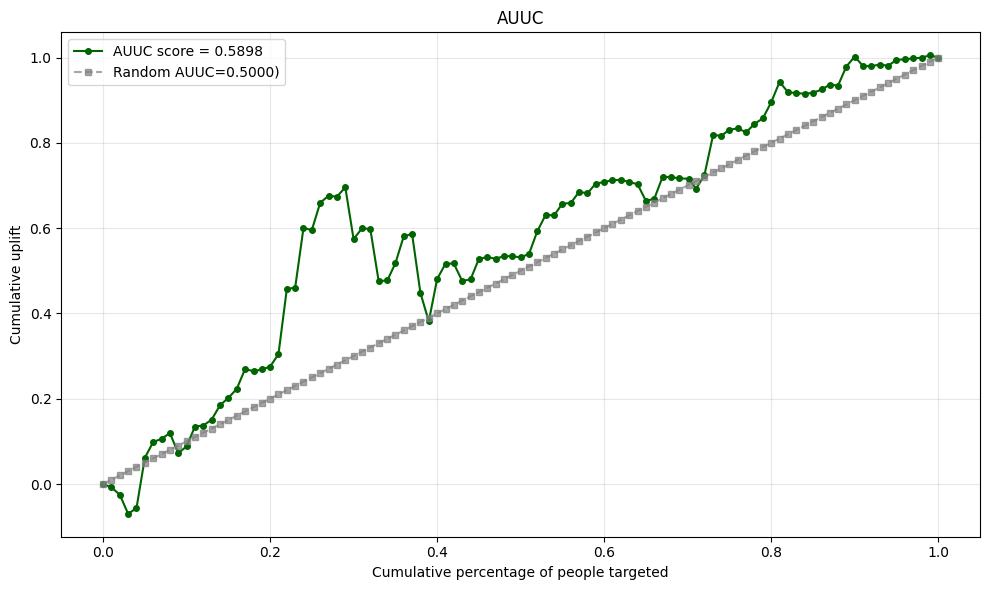

  Done Seed 412312
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: EMA_QINI
📊 Early Stop Start Epoch: 31
📊 Strategy: Best EMA Qini (alpha=0.35442964179936265)
   Restore to epoch with highest smoothed (EMA) Qini score
   Patience: 20 epochs
Epoch 1/150 | Loss: 2.0133 | Cls: 1.9500 | Reg: 2.4454 | mu_t: 4.4026 | sigma_t: 1.4140 | mu_c: 4.5028 | sigma_c: 0.9913 | Val Loss: 2.0266 | F1_c: 0.0000 | PR_AUC_c: 0.0072 | F1_t: 0.0370 | PR_AUC_t: 0.0360 | Val Qini: 0.8508 | EMA Qini: 0.8508 | Best EMA: 0.8508 ⭐ NEW BEST EMA
Epoch 2/150 | Loss: 1.1780 | Cls: 1.1487 | Reg: 1.1325 | mu_t: 4.4542 | sigma_t: 1.4320 | mu_c: 4.3297 | sigma_c: 0.8787 | Val Loss: 1.7766 | F1_c: 0.0000 | PR_AUC_c: 0.0085 | F1_t: 0.0370 | PR_AUC_t: 0.0326 | Val Qini: 0.8528 | EMA Qini: 0.8515 | Best EMA: 0.8515 ⭐ NEW BEST EMA
Epoch 3/150 | Loss: 2.3711 | Cls: 2.3127 | Reg: 2.2570 | mu_t: 4.4216 | sigma_t: 1.1531 | mu_c: 4.3193 | sigma_c: 0.9256 | Val Loss: 1.7637 | F1_c: 0.0000 | PR_AUC_c: 0.0083 | F1_t: 0.0370 | PR_AUC_

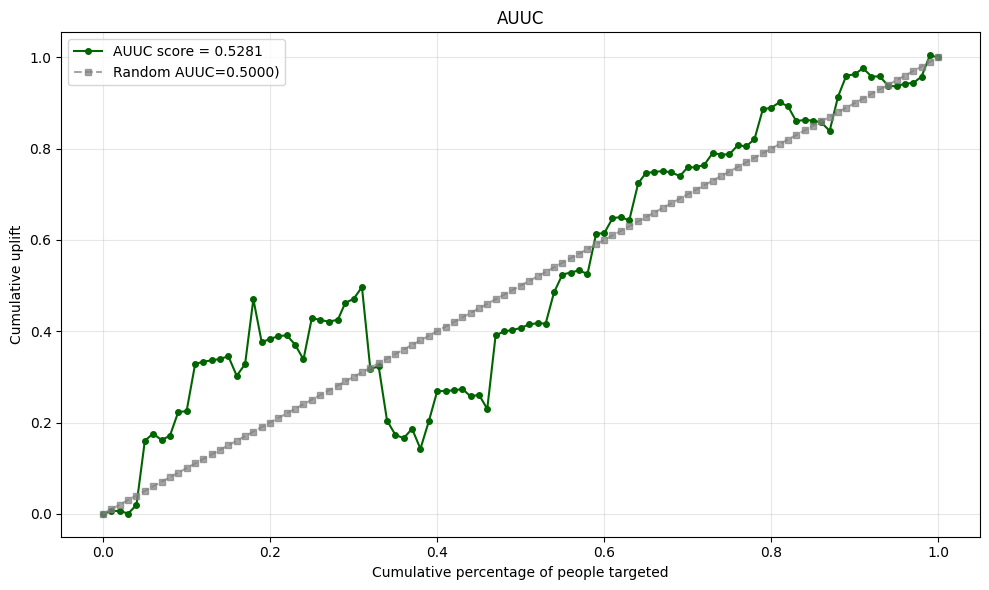

  Done Seed 42
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: EMA_QINI
📊 Early Stop Start Epoch: 31
📊 Strategy: Best EMA Qini (alpha=0.35442964179936265)
   Restore to epoch with highest smoothed (EMA) Qini score
   Patience: 20 epochs
Epoch 1/150 | Loss: 1.7002 | Cls: 1.6395 | Reg: 2.3465 | mu_t: 4.6102 | sigma_t: 1.1953 | mu_c: 4.6466 | sigma_c: 1.0155 | Val Loss: 1.9472 | F1_c: 0.0000 | PR_AUC_c: 0.0075 | F1_t: 0.0370 | PR_AUC_t: 0.0310 | Val Qini: 0.8616 | EMA Qini: 0.8616 | Best EMA: 0.8616 ⭐ NEW BEST EMA
Epoch 2/150 | Loss: 1.9438 | Cls: 1.8847 | Reg: 2.2873 | mu_t: 4.3886 | sigma_t: 1.1711 | mu_c: 4.3189 | sigma_c: 0.9958 | Val Loss: 1.8737 | F1_c: 0.0000 | PR_AUC_c: 0.0087 | F1_t: 0.0370 | PR_AUC_t: 0.0297 | Val Qini: 0.8265 | EMA Qini: 0.8492 | Best EMA: 0.8616 (patience: 0/20)
Epoch 3/150 | Loss: 1.8278 | Cls: 1.7837 | Reg: 1.7018 | mu_t: 4.2859 | sigma_t: 1.1705 | mu_c: 4.4370 | sigma_c: 0.9448 | Val Loss: 1.7070 | F1_c: 0.0000 | PR_AUC_c: 0.0082 | F1_t: 0.0370 | PR_AUC_t:

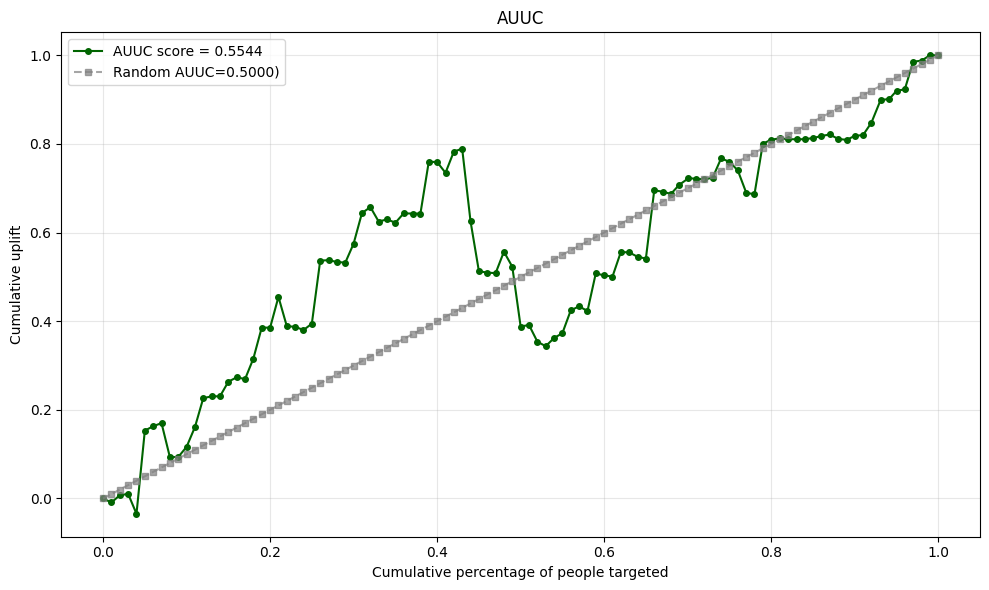

  Done Seed 1874
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: EMA_QINI
📊 Early Stop Start Epoch: 31
📊 Strategy: Best EMA Qini (alpha=0.35442964179936265)
   Restore to epoch with highest smoothed (EMA) Qini score
   Patience: 20 epochs
Epoch 1/150 | Loss: 2.0044 | Cls: 1.9565 | Reg: 1.8518 | mu_t: 4.3019 | sigma_t: 1.2615 | mu_c: 4.1910 | sigma_c: 1.1173 | Val Loss: 2.1720 | F1_c: 0.0000 | PR_AUC_c: 0.0084 | F1_t: 0.0370 | PR_AUC_t: 0.0252 | Val Qini: 0.8308 | EMA Qini: 0.8308 | Best EMA: 0.8308 ⭐ NEW BEST EMA
Epoch 2/150 | Loss: 1.6352 | Cls: 1.5904 | Reg: 1.7283 | mu_t: 4.6002 | sigma_t: 1.1611 | mu_c: 4.3169 | sigma_c: 1.0680 | Val Loss: 1.7733 | F1_c: 0.0000 | PR_AUC_c: 0.0090 | F1_t: 0.0741 | PR_AUC_t: 0.0290 | Val Qini: 0.8518 | EMA Qini: 0.8382 | Best EMA: 0.8382 ⭐ NEW BEST EMA
Epoch 3/150 | Loss: 2.0341 | Cls: 1.9876 | Reg: 1.7953 | mu_t: 4.2546 | sigma_t: 1.0836 | mu_c: 4.3569 | sigma_c: 0.9491 | Val Loss: 1.8577 | F1_c: 0.0000 | PR_AUC_c: 0.0090 | F1_t: 0.0741 | PR_AUC_t:

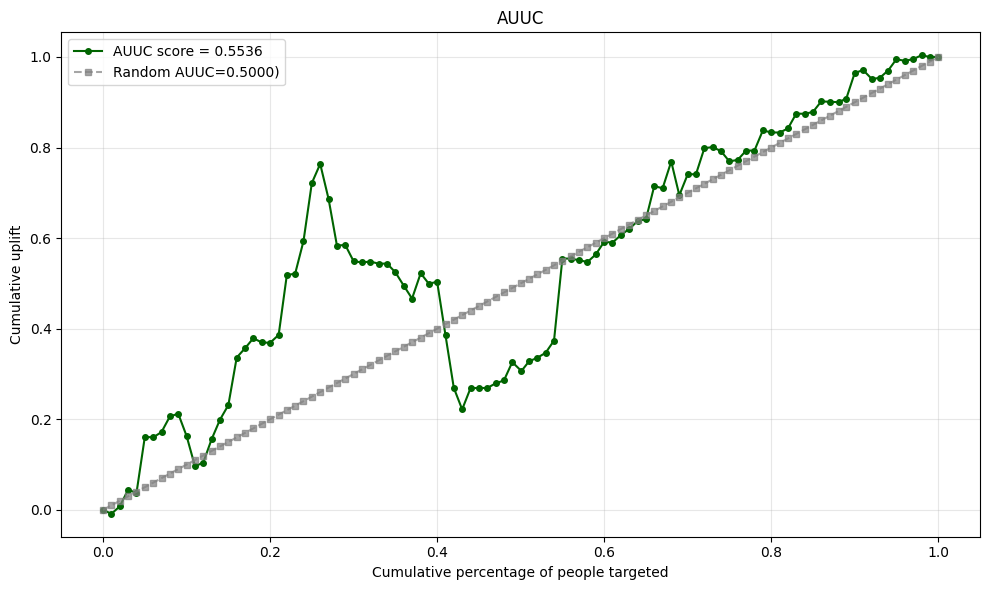

  Done Seed 902745
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: EMA_QINI
📊 Early Stop Start Epoch: 31
📊 Strategy: Best EMA Qini (alpha=0.35442964179936265)
   Restore to epoch with highest smoothed (EMA) Qini score
   Patience: 20 epochs
Epoch 1/150 | Loss: 1.6920 | Cls: 1.6545 | Reg: 1.4465 | mu_t: 4.1349 | sigma_t: 1.3885 | mu_c: 4.4407 | sigma_c: 1.1220 | Val Loss: 1.8707 | F1_c: 0.0000 | PR_AUC_c: 0.0083 | F1_t: 0.0741 | PR_AUC_t: 0.0325 | Val Qini: 0.8441 | EMA Qini: 0.8441 | Best EMA: 0.8441 ⭐ NEW BEST EMA
Epoch 2/150 | Loss: 1.5795 | Cls: 1.5303 | Reg: 1.9000 | mu_t: 4.2995 | sigma_t: 1.3264 | mu_c: 4.3271 | sigma_c: 1.0917 | Val Loss: 1.7985 | F1_c: 0.0000 | PR_AUC_c: 0.0084 | F1_t: 0.0741 | PR_AUC_t: 0.0302 | Val Qini: 0.8282 | EMA Qini: 0.8384 | Best EMA: 0.8441 (patience: 0/20)
Epoch 3/150 | Loss: 1.7012 | Cls: 1.6621 | Reg: 1.5112 | mu_t: 4.3440 | sigma_t: 1.1943 | mu_c: 4.3991 | sigma_c: 1.0953 | Val Loss: 1.7600 | F1_c: 0.0000 | PR_AUC_c: 0.0084 | F1_t: 0.0741 | PR_AU

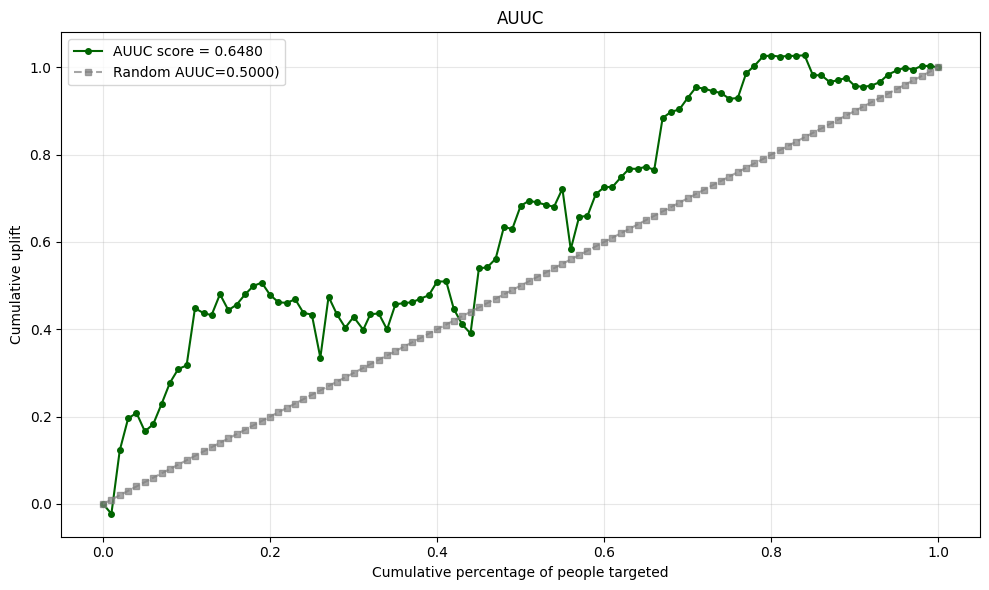

  Done Seed 1
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: EMA_QINI
📊 Early Stop Start Epoch: 31
📊 Strategy: Best EMA Qini (alpha=0.35442964179936265)
   Restore to epoch with highest smoothed (EMA) Qini score
   Patience: 20 epochs
Epoch 1/150 | Loss: 1.7265 | Cls: 1.6855 | Reg: 1.5847 | mu_t: 4.3419 | sigma_t: 1.3604 | mu_c: 4.3496 | sigma_c: 1.0644 | Val Loss: 1.6874 | F1_c: 0.0000 | PR_AUC_c: 0.0067 | F1_t: 0.0370 | PR_AUC_t: 0.0299 | Val Qini: 0.8761 | EMA Qini: 0.8761 | Best EMA: 0.8761 ⭐ NEW BEST EMA
Epoch 2/150 | Loss: 1.7191 | Cls: 1.6835 | Reg: 1.3751 | mu_t: 4.4398 | sigma_t: 1.3588 | mu_c: 4.3603 | sigma_c: 1.1563 | Val Loss: 1.8362 | F1_c: 0.0000 | PR_AUC_c: 0.0084 | F1_t: 0.0741 | PR_AUC_t: 0.0326 | Val Qini: 0.8622 | EMA Qini: 0.8712 | Best EMA: 0.8761 (patience: 0/20)
Epoch 3/150 | Loss: 1.4261 | Cls: 1.3871 | Reg: 1.5057 | mu_t: 4.4060 | sigma_t: 1.1188 | mu_c: 4.3744 | sigma_c: 1.0192 | Val Loss: 1.6341 | F1_c: 0.0000 | PR_AUC_c: 0.0080 | F1_t: 0.0741 | PR_AUC_t: 

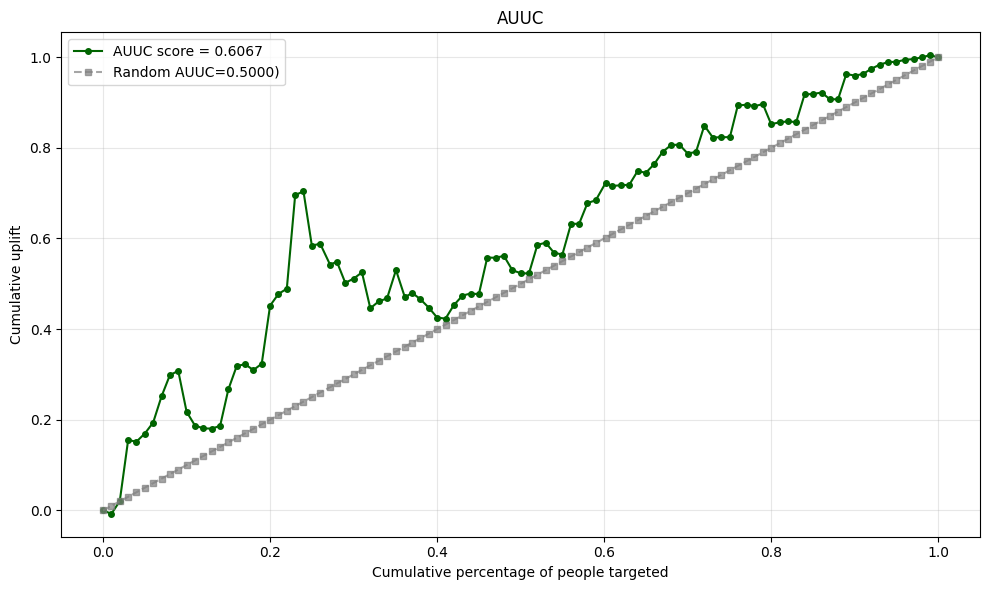

  Done Seed 2
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: EMA_QINI
📊 Early Stop Start Epoch: 31
📊 Strategy: Best EMA Qini (alpha=0.35442964179936265)
   Restore to epoch with highest smoothed (EMA) Qini score
   Patience: 20 epochs
Epoch 1/150 | Loss: 1.9383 | Cls: 1.8890 | Reg: 1.9075 | mu_t: 4.0374 | sigma_t: 1.3827 | mu_c: 4.3306 | sigma_c: 0.9546 | Val Loss: 2.2423 | F1_c: 0.0000 | PR_AUC_c: 0.0074 | F1_t: 0.0370 | PR_AUC_t: 0.0315 | Val Qini: 0.8079 | EMA Qini: 0.8079 | Best EMA: 0.8079 ⭐ NEW BEST EMA
Epoch 2/150 | Loss: 2.5013 | Cls: 2.4446 | Reg: 2.1898 | mu_t: 4.3874 | sigma_t: 1.3523 | mu_c: 4.3853 | sigma_c: 1.0058 | Val Loss: 1.6279 | F1_c: 0.0000 | PR_AUC_c: 0.0081 | F1_t: 0.0370 | PR_AUC_t: 0.0329 | Val Qini: 0.7971 | EMA Qini: 0.8041 | Best EMA: 0.8079 (patience: 0/20)
Epoch 3/150 | Loss: 1.3330 | Cls: 1.2810 | Reg: 2.0087 | mu_t: 4.3584 | sigma_t: 1.2441 | mu_c: 4.3317 | sigma_c: 0.9044 | Val Loss: 1.7926 | F1_c: 0.0000 | PR_AUC_c: 0.0081 | F1_t: 0.0370 | PR_AUC_t: 

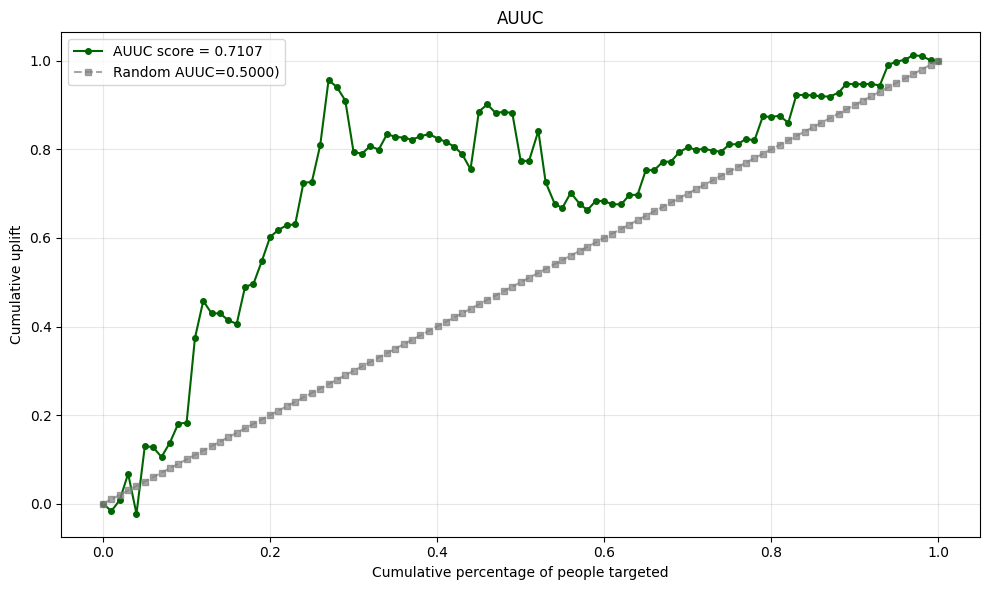

  Done Seed 3
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: EMA_QINI
📊 Early Stop Start Epoch: 31
📊 Strategy: Best EMA Qini (alpha=0.35442964179936265)
   Restore to epoch with highest smoothed (EMA) Qini score
   Patience: 20 epochs
Epoch 1/150 | Loss: 1.8938 | Cls: 1.8460 | Reg: 1.8458 | mu_t: 4.3746 | sigma_t: 1.3078 | mu_c: 4.6196 | sigma_c: 1.0281 | Val Loss: 2.0253 | F1_c: 0.0000 | PR_AUC_c: 0.0071 | F1_t: 0.0370 | PR_AUC_t: 0.0263 | Val Qini: 0.8190 | EMA Qini: 0.8190 | Best EMA: 0.8190 ⭐ NEW BEST EMA
Epoch 2/150 | Loss: 2.1762 | Cls: 2.1019 | Reg: 2.8728 | mu_t: 4.2538 | sigma_t: 1.2231 | mu_c: 4.3374 | sigma_c: 0.8759 | Val Loss: 1.8841 | F1_c: 0.0000 | PR_AUC_c: 0.0077 | F1_t: 0.0741 | PR_AUC_t: 0.0290 | Val Qini: 0.8353 | EMA Qini: 0.8248 | Best EMA: 0.8248 ⭐ NEW BEST EMA
Epoch 3/150 | Loss: 1.7818 | Cls: 1.7285 | Reg: 2.0608 | mu_t: 4.3472 | sigma_t: 1.1533 | mu_c: 4.5320 | sigma_c: 1.0132 | Val Loss: 1.8897 | F1_c: 0.0000 | PR_AUC_c: 0.0076 | F1_t: 0.0370 | PR_AUC_t: 0.

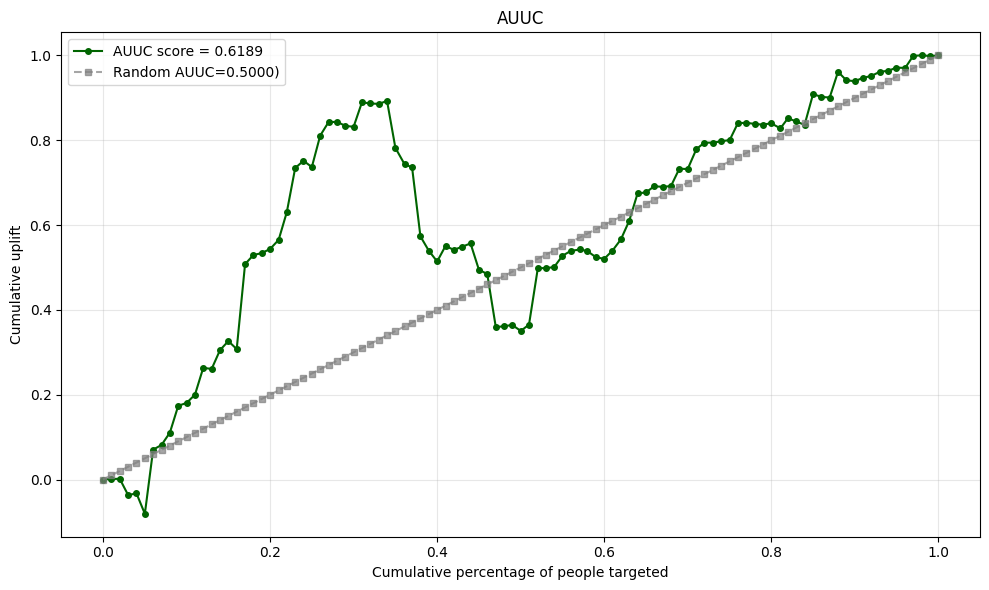

  Done Seed 4
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: EMA_QINI
📊 Early Stop Start Epoch: 31
📊 Strategy: Best EMA Qini (alpha=0.35442964179936265)
   Restore to epoch with highest smoothed (EMA) Qini score
   Patience: 20 epochs
Epoch 1/150 | Loss: 1.3783 | Cls: 1.3583 | Reg: 0.7727 | mu_t: 4.6478 | sigma_t: 1.2706 | mu_c: 4.1673 | sigma_c: 1.0239 | Val Loss: 2.2357 | F1_c: 0.0000 | PR_AUC_c: 0.0081 | F1_t: 0.0370 | PR_AUC_t: 0.0294 | Val Qini: 0.8615 | EMA Qini: 0.8615 | Best EMA: 0.8615 ⭐ NEW BEST EMA
Epoch 2/150 | Loss: 1.5178 | Cls: 1.4662 | Reg: 1.9936 | mu_t: 4.4030 | sigma_t: 1.3319 | mu_c: 4.3938 | sigma_c: 1.0354 | Val Loss: 2.0311 | F1_c: 0.0000 | PR_AUC_c: 0.0090 | F1_t: 0.0370 | PR_AUC_t: 0.0309 | Val Qini: 0.8490 | EMA Qini: 0.8571 | Best EMA: 0.8615 (patience: 0/20)
Epoch 3/150 | Loss: 2.2073 | Cls: 2.1558 | Reg: 1.9909 | mu_t: 4.3153 | sigma_t: 1.2494 | mu_c: 4.2613 | sigma_c: 0.9713 | Val Loss: 1.8702 | F1_c: 0.0000 | PR_AUC_c: 0.0076 | F1_t: 0.0370 | PR_AUC_t: 

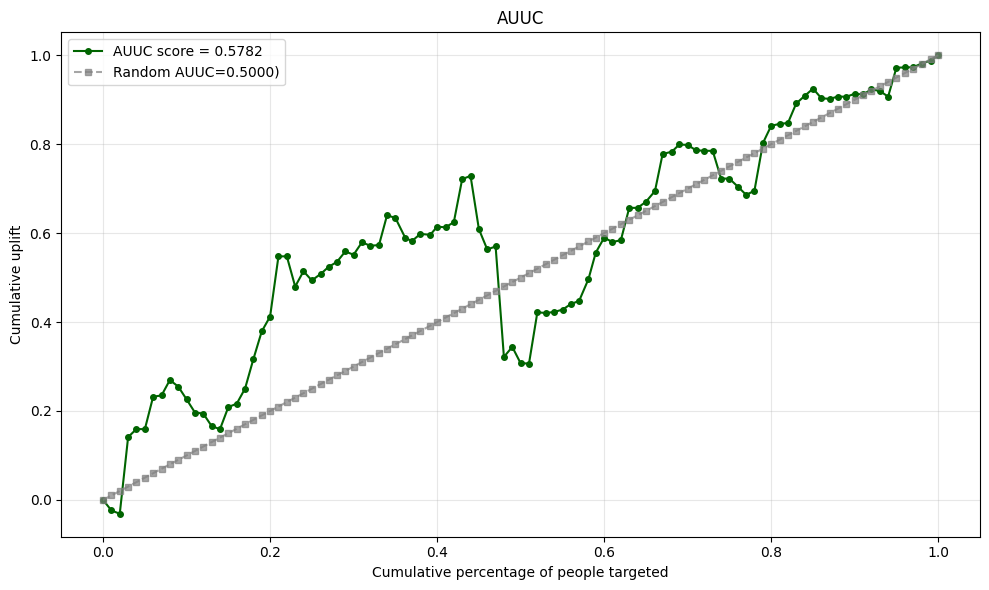

  Done Seed 5
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: EMA_QINI
📊 Early Stop Start Epoch: 31
📊 Strategy: Best EMA Qini (alpha=0.35442964179936265)
   Restore to epoch with highest smoothed (EMA) Qini score
   Patience: 20 epochs
Epoch 1/150 | Loss: 0.9395 | Cls: 0.9261 | Reg: 0.5160 | mu_t: 4.3031 | sigma_t: 1.4030 | mu_c: 4.4623 | sigma_c: 0.9338 | Val Loss: 1.7943 | F1_c: 0.0000 | PR_AUC_c: 0.0084 | F1_t: 0.0370 | PR_AUC_t: 0.0332 | Val Qini: 0.6276 | EMA Qini: 0.6276 | Best EMA: 0.6276 ⭐ NEW BEST EMA
Epoch 2/150 | Loss: 1.7409 | Cls: 1.6949 | Reg: 1.7768 | mu_t: 4.4419 | sigma_t: 1.1719 | mu_c: 4.4323 | sigma_c: 1.1657 | Val Loss: 1.8480 | F1_c: 0.0000 | PR_AUC_c: 0.0087 | F1_t: 0.0370 | PR_AUC_t: 0.0289 | Val Qini: 0.7981 | EMA Qini: 0.6881 | Best EMA: 0.6881 ⭐ NEW BEST EMA
Epoch 3/150 | Loss: 1.8839 | Cls: 1.8274 | Reg: 2.1844 | mu_t: 4.4608 | sigma_t: 1.0459 | mu_c: 4.4328 | sigma_c: 0.9988 | Val Loss: 2.1199 | F1_c: 0.0000 | PR_AUC_c: 0.0089 | F1_t: 0.0741 | PR_AUC_t: 0.

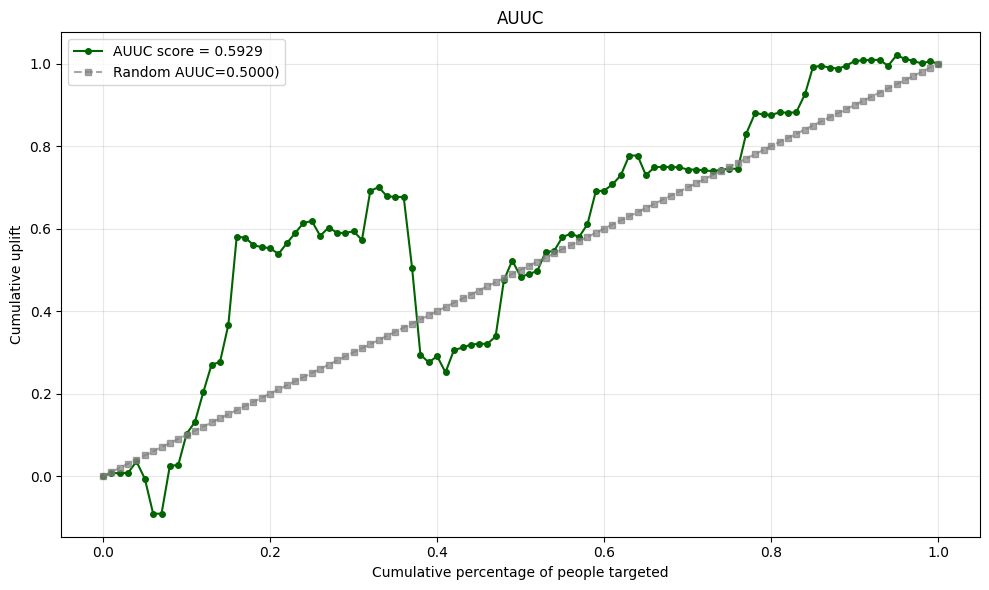

  Done Seed 6

                             PER-SEED DETAILS (TEST SET)                             
  Seed   AUUC   AUQC   Lift   KRCC ATE_Err
412312 0.5898 0.5909 1.1235 0.0744 20.7656
    42 0.5281 0.5310 0.9226 0.0355  8.4082
  1874 0.5544 0.5549 1.1259 0.0204  6.4200
902745 0.5536 0.5555 1.0756 0.0285  9.9687
     1 0.6480 0.6510 0.8378 0.0647 13.5890
     2 0.6067 0.6105 1.0002 0.0725  8.7816
     3 0.7107 0.7090 1.5545 0.0436 10.8269
     4 0.6189 0.6186 1.6290 0.0626 12.1538
     5 0.5782 0.5810 1.0802 0.0128 10.0060
     6 0.5929 0.5944 1.1615 0.0707  8.2674
                              TEST SUMMARY (MEAN ± STD)                              
-------------------------------------------------------------------------------------
AUUC      : 0.5981 ± 0.0527
AUQC      : 0.5997 ± 0.0518
Lift      : 1.1511 ± 0.2531
KRCC      : 0.0486 ± 0.0232
ATE_Err   : 10.9187 ± 4.0208


In [11]:
import pandas as pd
import numpy as np
import torch

# 1. Evaluate selected config on test set (after tuning)
seeds = [412312, 42, 1874, 902745, 1, 2, 3, 4, 5, 6]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
all_runs = []

if 'best_cfg' not in globals():
    raise ValueError("best_cfg not found. Run grid-search cell first.")

best_lr = float(best_cfg['lr'])
best_wd = float(best_cfg['weight_decay'])
best_shared_hidden = int(best_cfg['shared_hidden'])
best_outcome_hidden = int(best_cfg['outcome_hidden'])
best_shared_dropout = float(best_cfg['shared_dropout'])
best_outcome_dropout = float(best_cfg['outcome_dropout'])
best_ziln_lambda = float(best_cfg['ziln_lambda'])
best_pos_weight = float(best_cfg['pos_weight'])
best_ema_alpha = float(best_cfg['ema_alpha'])

print("Evaluating on test with best validation config:")
print(f"  lr={best_lr:.1e}, weight_decay={best_wd:.1e}")
print(f"  shared_hidden={best_shared_hidden}, outcome_hidden={best_outcome_hidden}")
print(f"  shared_dropout={best_shared_dropout:.3f}, outcome_dropout={best_outcome_dropout:.3f}")
print(f"  ema_alpha={best_ema_alpha:.3f}")
print(f"Number of seeds: {len(seeds)}")

# 2. Loop over seeds for robust test evaluation
for SEED in seeds:
    seed_everything(SEED)

    tarnet = Tarnet(
        cate_dims=cat_dims,
        num_count=num_count,
        epochs=epochs,
        learning_rate=best_lr,
        weight_decay=best_wd,
        use_ema=ema,
        ema_alpha=best_ema_alpha,
        patience=patience,
        shared_hidden=best_shared_hidden,
        outcome_hidden=best_outcome_hidden,
        outcome_dropout=best_outcome_dropout,
        shared_dropout=best_shared_dropout,
        early_stop_metric=early_stop_metric,
        early_stop_start_epoch=early_stop_start,
        ziln_lambda=best_ziln_lambda,
        pos_weight=best_pos_weight
    )

    tarnet.fit(train_loader, val_loader)

   # Test prediction
    test_cat_device = test_cat.to(device)
    test_num_device = test_num.to(device)
    y0_pred, y1_pred = tarnet.predict(test_cat_device, test_num_device)

    uplift_pred = (y1_pred - y0_pred).detach().cpu().numpy().flatten()
    y_true = y_test.detach().cpu().numpy().flatten()
    t_true = t_test.detach().cpu().numpy().flatten()

    # ATE error
    ate_pred = uplift_pred.mean()
    ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

    all_runs.append({
        'Seed': SEED,
        'AUUC': auuc(y_true, t_true, uplift_pred, bins=100, plot=True),
        'AUQC': auqc(y_true, t_true, uplift_pred, bins=100, plot=False),
        'Lift': lift(y_true, t_true, uplift_pred, h=0.3),
        'KRCC': krcc(y_true, t_true, uplift_pred, bins=100),
        'ATE_Err': abs(ate_pred - ate_true)
    })
    print(f"  Done Seed {SEED}")

# 3. Aggregate final test metrics
df_results = pd.DataFrame(all_runs)

print("\n" + "=" * 85)
print(f"{'PER-SEED DETAILS (TEST SET)':^85}")
print("=" * 85)
print(df_results.to_string(index=False, formatters={
    'AUUC': '{:,.4f}'.format,
    'AUQC': '{:,.4f}'.format,
    'Lift': '{:,.4f}'.format,
    'KRCC': '{:,.4f}'.format,
    'ATE_Err': '{:,.4f}'.format
}))

mean_res = df_results.drop(columns='Seed').mean()
std_res = df_results.drop(columns='Seed').std()

print("=" * 85)
print(f"{'TEST SUMMARY (MEAN ± STD)':^85}")
print("-" * 85)
for metric in ['AUUC', 'AUQC', 'Lift', 'KRCC', 'ATE_Err']:
    print(f"{metric:<10}: {mean_res[metric]:.4f} ± {std_res[metric]:.4f}")
print("=" * 85)